In [2]:
import pandas as pd
import numpy as np
import joblib
import re

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import linear_kernel


In [2]:
# Load dataframe (order MUST match TF-IDF training)
df = pd.read_csv("final_copy.csv")

# Load TF-IDF artifacts
tfidf_matrix = joblib.load("tfidf_matrix.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")  # kept for safety


In [3]:
indices = pd.Series(df.index, index=df['title']).to_dict()


In [54]:
def normalize_title(title):
    if not isinstance(title, str):
        return ""

    title = title.lower()
    title = re.sub(r'\b(part|chapter|episode)\b', '', title)
    title = re.sub(r'\b(ii|iii|iv|v|\d+)\b', '', title)
    title = re.sub(r'[^a-z0-9 ]', '', title)
    return title.strip()


In [55]:
def sequel_score(base_title, candidate_title):
    base_norm = normalize_title(base_title)
    cand_norm = normalize_title(candidate_title)

    if base_norm == cand_norm:
        return 1.0          # direct sequel / same franchise
    if base_norm in cand_norm or cand_norm in base_norm:
        return 0.6          # loose sequel / spin-off
    return 0.0


In [56]:
def popularity_boost(vote_count):
    if vote_count <= 0:
        return 0.0
    return np.log1p(vote_count)


In [68]:
# Create the movie index map
# We use drop_duplicates so that one title maps to one index
movie_index_map = pd.Series(
    df.index, 
    index=df["title"]
).drop_duplicates()

print(f"Index map created for {len(movie_index_map)} unique movies.")

Index map created for 503398 unique movies.


### this code was also good but calculated cosine matrix on whole dataset every time.
def get_recommendations(
    title,
    n=10,
    alpha=0.85,
    beta=0.15
):
    idx = indices[title]

    # Compute similarity: ONE movie vs ALL
    cosine_scores = linear_kernel(
        tfidf_matrix[idx:idx+1],
        tfidf_matrix
    ).flatten()

    scored_movies = []

    for i, content_score in enumerate(cosine_scores):
        seq_boost = sequel_score(title, df.iloc[i]['title'])
        pop_boost = popularity_boost(df.iloc[i]['vote_count'])
        final_score = (
            alpha * content_score
            + beta * seq_boost
            + 0.05 * pop_boost
        )

        scored_movies.append((i, final_score))

    scored_movies = sorted(scored_movies, key=lambda x: x[1], reverse=True)
    scored_movies = scored_movies[1:n+1]

    return df.iloc[[i[0] for i in scored_movies]][
        ['title', 'genres', 'vote_count', 'release_date']
    ]


In [73]:
!pip install thefuzz

In [82]:
import numpy as np
import pandas as pd
from thefuzz import process, fuzz
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

def get_recommendations(title, n=12, alpha=0.85, beta=0.15):
    # 1. ENSURE MAP EXISTS
    global movie_index_map
    if 'movie_index_map' not in globals():
        movie_index_map = pd.Series(df.index, index=df["title"]).drop_duplicates()

    # 2. BETTER FUZZY MATCHING (WRatio handles partials like "Avata" better)
    all_titles = df['title'].unique()
    best_match, score = process.extractOne(title, all_titles, scorer=fuzz.WRatio)
    
    if score < 60 or len(title.strip()) < 3:
        print(f"⚠️ Search term '{title}' is too vague to provide accurate recommendations.")
        return None
    
    # 3. GET INDEX
    idx_entry = movie_index_map[best_match]
    idx = idx_entry.iloc[0] if isinstance(idx_entry, pd.Series) else idx_entry
    
    # 4. SIMILARITY & LOG POPULARITY
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    log_pop = np.log1p(df['vote_count'])
    pop_norm = (log_pop - log_pop.min()) / (log_pop.max() - log_pop.min())
    
    # 5. HYBRID CALCULATION
    hybrid_scores = (alpha * sim_scores) + (beta * pop_norm.values)
    
    # 6. EFFICIENT TOP-K SELECTION
    k = n + 1
    partition_idx = np.argpartition(hybrid_scores, -k)[-k:]
    top_indices = partition_idx[np.argsort(hybrid_scores[partition_idx])[::-1]]
    top_indices = [i for i in top_indices if i != idx][:n]
    
    # 7. FORMATTED OUTPUT
    res = df.iloc[top_indices][['title', 'genres', 'vote_count']].copy()
    res['similarity'] = sim_scores[top_indices]
    res['hybrid_score'] = hybrid_scores[top_indices]
    
    # --- THE FIX ---
    # This resets the index so you don't see original row numbers like 407274
    res = res.reset_index(drop=True)
    
    print(f"✅ Found matches for: '{best_match}'")
    return res

print("DF shape:", df.shape)
print("TF-IDF shape:", tfidf_matrix.shape)

assert df.shape[0] == tfidf_matrix.shape[0], "Row mismatch: DF vs TF-IDF"
assert 'title' in df.columns, "Missing title column"

print("Basic sanity checks passed ✅")


In [59]:
test_title = df['title'].iloc[0]

print("Testing title:", test_title)
print("Mapped index:", indices[test_title])


Testing title: Ariel
Mapped index: 440843


In [60]:
get_recommendations(
    title=df['title'].iloc[0],
    n=10
)

,title,genres,vote_count,release_date
440843,Ariel,"Drama, Fantasy",1.0,2025-12-25
83196,Mood Indigo,"Drama, Fantasy",641.0,2013-01-10
11637,The Exterminating Angels,"Drama, Fantasy",73.0,2006-09-13
94521,Salto,"Drama, Fantasy",25.0,1965-06-10
68447,The Seashell and the Clergyman,"Drama, Fantasy",68.0,1928-10-01
351976,The Skin Painter,"Drama, Fantasy",1.0,2018-04-21
351936,War of Fantasy,"Drama, Fantasy",1.0,2018-05-12
349222,One and Four,"Drama, Fantasy",21.0,2023-10-27
352868,Hello Lord Xuan,"Drama, Fantasy",1.0,2018-05-02
384592,Aníkúlápó,"Drama, Fantasy",40.0,2022-09-30


In [63]:
get_recommendations(
    "The Martian",
    n = 15,
    alpha = 0.7,
    beta = 0.20
)

,title,genres,vote_count,release_date
133065,The Martian,"Drama, Adventure, Science Fiction",20771.0,2015-09-30
300988,65,"Action, Adventure, Science Fiction",2718.0,2023-03-02
905,The Fountain,"Drama, Adventure, Science Fiction, Romance",2973.0,2006-11-22
247145,Everything Everywhere All at Once,"Action, Adventure, Science Fiction",7586.0,2022-03-24
690,Total Recall,"Action, Adventure, Science Fiction",6259.0,1990-06-01
335520,Godzilla x Kong: The New Empire,"Action, Adventure, Science Fiction",4466.0,2024-03-27
1475,Stargate,"Action, Adventure, Science Fiction",3681.0,1994-10-28
4420,Mad Max Beyond Thunderdome,"Action, Adventure, Science Fiction",3162.0,1985-06-29
170149,The Space Between Us,"Romance, Adventure, Science Fiction, Drama",2518.0,2017-01-26
316224,The Moon,"Drama, Adventure, Science Fiction",190.0,2023-08-02


In [49]:
get_recommendations(
    'Frankenstein',
    n=10,
    alpha=0.85,
    beta=0.15
)

,title,genres,vote_count,release_date
489494,Frankenstein,"Animation, Horror",0.0,1978-01-01
27698,The Grandmother,"Animation, Horror",172.0,1970-07-01
344430,Night of the Animated Dead,"Animation, Horror",117.0,2021-09-21
7724,Resident Evil: Degeneration,"Animation, Horror, Action, Science Fiction",1140.0,2008-02-13
96213,The Amazing Adventures of the Living Corpse,"Animation, Horror",20.0,2012-07-14
170258,To Your Last Death,"Animation, Horror",56.0,2019-11-30
87913,The Curse of Kazuo Umezu,"Animation, Horror",20.0,1990-03-01
30630,Urotsukidōji III: Return of the Overfiend,"Animation, Horror",96.0,1993-12-31
43382,Tales of the Brothers Quay,"Animation, Horror",5.0,1987-07-04
317053,A Creepshow Animated Special,"Animation, Horror",33.0,2020-10-29


In [40]:
tfidf_matrix.shape

(503398, 50000)

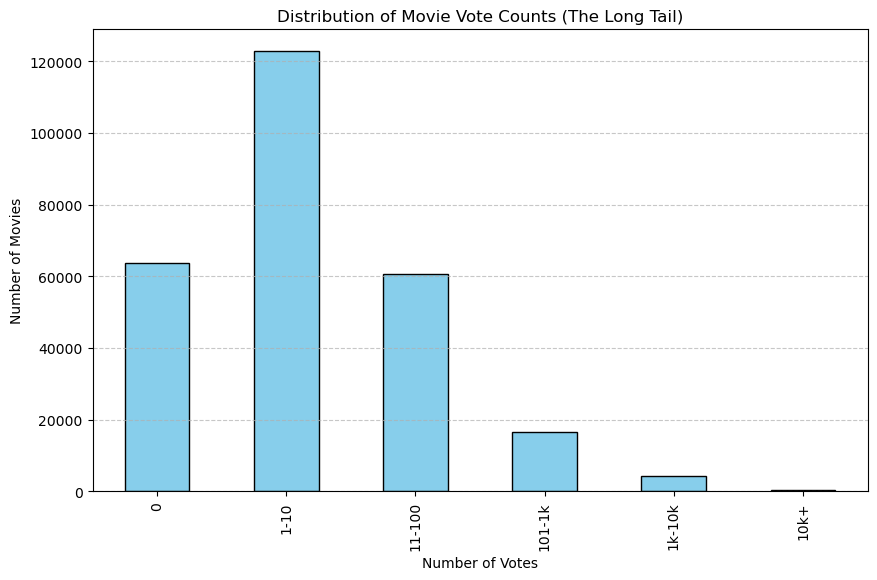

In [51]:
import matplotlib.pyplot as plt

# Create buckets for vote counts
bins = [0, 1, 10, 100, 1000, 10000, df['vote_count'].max()]
labels = ['0', '1-10', '11-100', '101-1k', '1k-10k', '10k+']
vote_dist = pd.cut(df['vote_count'].fillna(0), bins=bins, labels=labels).value_counts().sort_index()

plt.figure(figsize=(10, 6))
vote_dist.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Movie Vote Counts (The Long Tail)')
plt.xlabel('Number of Votes')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [77]:
get_recommendations("Avenger", n=12, alpha=0.85, beta=0.15)

✅ Found matches for: 'Captain America: The First Avenger'


,title,genres,vote_count,similarity,hybrid_score
4420,Mad Max Beyond Thunderdome,"Action, Adventure, Science Fiction",3162.0,0.365001,0.424685
43522,Iron Man 3,"Action, Adventure, Science Fiction",23064.0,0.331588,0.424496
247145,Everything Everywhere All at Once,"Action, Adventure, Science Fiction",7586.0,0.349766,0.424158
335520,Godzilla x Kong: The New Empire,"Action, Adventure, Science Fiction",4466.0,0.357451,0.423170
1475,Stargate,"Action, Adventure, Science Fiction",3681.0,0.358519,0.421333
60662,Captain America: The Winter Soldier,"Action, Adventure, Science Fiction",19674.0,0.320064,0.412442
140234,Captain Marvel,"Action, Adventure, Science Fiction",16472.0,0.319411,0.409365
4610,Timeline,"Action, Adventure, Science Fiction",1137.0,0.360897,0.406682
26159,The Girl from Rio,"Action, Adventure, Science Fiction",41.0,0.415114,0.405919
48281,Mad Max: Fury Road,"Action, Adventure, Science Fiction",23695.0,0.299715,0.397786


In [83]:
get_recommendations("Avata", n=12, alpha=0.85, beta=0.15)

✅ Found matches for: 'Avatar'


,title,genres,vote_count,similarity,hybrid_score
0,Krull,"Action, Adventure, Fantasy, Science Fiction",597.0,0.525988,0.537873
1,The 25th Reich,"Action, Adventure, Fantasy, Science Fiction",27.0,0.575733,0.536687
2,The Scorpion King 2: Rise of a Warrior,"Action, Adventure, Fantasy, Science Fiction",614.0,0.468088,0.489057
3,A World of Worlds,"Action, Adventure, Fantasy, Science Fiction",3.0,0.549690,0.486921
4,The Final Level: Escaping Rancala,"Action, Adventure, Fantasy, Science Fiction",28.0,0.503861,0.476094
5,Godzilla vs. Mothra,"Action, Adventure, Fantasy, Science Fiction",215.0,0.468122,0.474228
6,The Jethroverse Holiday Special,"Action, Adventure, Fantasy, Science Fiction",0.0,0.551373,0.468667
7,Beastmaster 2: Through the Portal of Time,"Action, Adventure, Fantasy, Science Fiction",73.0,0.478987,0.468253
8,Gods of Egypt,"Action, Adventure, Fantasy",4247.0,0.364742,0.428653
9,Avatar: The Way of Water,"Action, Adventure, Science Fiction",13595.0,0.345219,0.428577


In [86]:
get_recommendations("krull", n=12, alpha=0.85, beta=0.15)

✅ Found matches for: 'Krull'


,title,genres,vote_count,similarity,hybrid_score
0,Avatar,"Action, Adventure, Fantasy, Science Fiction",33340.0,0.525988,0.594967
1,The 25th Reich,"Action, Adventure, Fantasy, Science Fiction",27.0,0.576412,0.537265
2,A World of Worlds,"Action, Adventure, Fantasy, Science Fiction",3.0,0.584533,0.516538
3,The Scorpion King 2: Rise of a Warrior,"Action, Adventure, Fantasy, Science Fiction",614.0,0.481540,0.500491
4,Godzilla vs. Mothra,"Action, Adventure, Fantasy, Science Fiction",215.0,0.481574,0.485662
5,The Jethroverse Holiday Special,"Action, Adventure, Fantasy, Science Fiction",0.0,0.567218,0.482135
6,The Final Level: Escaping Rancala,"Action, Adventure, Fantasy, Science Fiction",28.0,0.510775,0.481972
7,Beastmaster 2: Through the Portal of Time,"Action, Adventure, Fantasy, Science Fiction",73.0,0.492752,0.479953
8,Gods of Egypt,"Action, Adventure, Fantasy",4247.0,0.375224,0.437562
9,Dragonball Evolution,"Action, Adventure, Fantasy, Science Fiction, T...",2165.0,0.385338,0.436596


In [87]:
get_recommendations("guardians of the gal", n=12, alpha=0.85, beta=0.15)

✅ Found matches for: 'Guardians of the Galaxy'


,title,genres,vote_count,similarity,hybrid_score
0,Heavy Armor 4: Monster Attack,"Action, Science Fiction, Adventure",0.0,0.633548,0.538516
1,Alita: Battle Angel,"Action, Science Fiction, Adventure",9753.0,0.442289,0.506371
2,Babylon 5: The River of Souls,"Action, Science Fiction, Adventure",109.0,0.516716,0.505951
3,Iron Man,"Action, Science Fiction, Adventure",27654.0,0.417789,0.500343
4,Predator: Badlands,"Action, Science Fiction, Adventure",1686.0,0.454504,0.491838
5,Thunderbolts*,"Action, Science Fiction, Adventure",3120.0,0.440417,0.488600
6,The Wolverine,"Action, Science Fiction, Adventure",10080.0,0.417378,0.485665
7,Godzilla vs. Kong,"Action, Science Fiction, Adventure",10442.0,0.411994,0.481589
8,Inception,"Action, Science Fiction, Adventure",38578.0,0.390022,0.481468
9,Battle of the Damned,"Action, Science Fiction, Adventure",135.0,0.473636,0.472346


In [89]:
get_recommendations("missiom impopssible ", n=12, alpha=0.85, beta=0.15)

✅ Found matches for: 'Mission Impossible'


,title,genres,vote_count,similarity,hybrid_score
0,Wouter Deprez: Eelt,"Drama, Action",2.0,0.505656,0.445407
1,Desperate,"Drama, Action",0.0,0.517908,0.440222
2,Hero Invitation,"Drama, Action",1.0,0.505656,0.439650
3,Vidas paralelas,"Drama, Action",1.0,0.505656,0.439650
4,The New Dragon Inn: Heroes Awakening,"Drama, Action",1.0,0.505656,0.439650
5,Психи,"Drama, Action",1.0,0.505656,0.439650
6,Kung Fu Duo,"Drama, Action",0.0,0.505656,0.429808
7,Fury Fist,"Drama, Action",0.0,0.505656,0.429808
8,Fearless,"Drama, Action",0.0,0.505656,0.429808
9,Faster: Only one lap,"Drama, Action",0.0,0.505656,0.429808


In [91]:
get_recommendations("missiom impopssible fallout", n=12, alpha=0.85, beta=0.15)

✅ Found matches for: 'Fallout'


,title,genres,vote_count,similarity,hybrid_score
0,Dawn of Destruction,"Action, Science Fiction",4.0,0.683984,0.604239
1,Ryujin Mabuyer The Movie: Nanatsu no Mabui,"Action, Science Fiction",2.0,0.683984,0.596985
2,Memory Swap,"Action, Science Fiction",0.0,0.683984,0.581386
3,Death: Download,"Action, Science Fiction",0.0,0.679649,0.577702
4,Time Lord,"Action, Science Fiction",0.0,0.666899,0.566864
5,Jikuu Keisatsu Hyperion,"Action, Science Fiction",0.0,0.656791,0.558272
6,Suzhou Youth Drift in Hengdian,"Action, Science Fiction",0.0,0.644421,0.547757
7,Immortal Kamen Rider Special,"Action, Science Fiction",3.0,0.619515,0.546272
8,Tôhôkenbunroku,"Action, Science Fiction",0.0,0.622087,0.528774
9,Support Droid Yurika,"Action, Science Fiction",0.0,0.617626,0.524982


In [92]:
get_recommendations("Dune", n=12, alpha=0.85, beta=0.15)

✅ Found matches for: 'Dune'


,title,genres,vote_count,similarity,hybrid_score
0,Alita: Battle Angel,"Action, Science Fiction, Adventure",9753.0,0.295772,0.381831
1,The Wolverine,"Action, Science Fiction, Adventure",10080.0,0.293069,0.380002
2,Iron Man,"Action, Science Fiction, Adventure",27654.0,0.275425,0.379334
3,Guardians of the Galaxy,"Action, Science Fiction, Adventure",29245.0,0.274172,0.379063
4,Godzilla vs. Kong,"Action, Science Fiction, Adventure",10442.0,0.288523,0.376638
5,A Touch of Spice,"Comedy, Drama",126.0,0.355812,0.371224
6,Babylon 5: The River of Souls,"Action, Science Fiction, Adventure",109.0,0.350845,0.364961
7,Thunderbolts*,"Action, Science Fiction, Adventure",3120.0,0.294521,0.364587
8,Predator: Badlands,"Action, Science Fiction, Adventure",1686.0,0.303941,0.363859
9,Heavy Armor 4: Monster Attack,"Action, Science Fiction, Adventure",0.0,0.423673,0.360122


In [93]:
get_recommendations("Blade Runner", n=12, alpha=0.85, beta=0.15)

✅ Found matches for: 'Blade Runner'


,title,genres,vote_count,similarity,hybrid_score
0,Primer,"Science Fiction, Drama, Thriller",2319.0,0.417254,0.464699
1,Chronicle,"Science Fiction, Drama, Thriller",5590.0,0.383925,0.448859
2,The Show Must Go On,"Science Fiction, Drama, Thriller",8.0,0.474997,0.434946
3,The Reconstruction of William Zero,"Science Fiction, Drama, Thriller",38.0,0.441624,0.427400
4,Blade Runner 2049,"Science Fiction, Drama",14715.0,0.327285,0.414457
5,The Assessment,"Science Fiction, Drama, Thriller",356.0,0.379496,0.406030
6,Rani Rani Rani,"Science Fiction, Drama, Thriller",4.0,0.449192,0.404666
7,Agency,"Science Fiction, Drama, Thriller",10.0,0.428626,0.398380
8,These Final Hours,"Science Fiction, Drama, Thriller",593.0,0.356794,0.393963
9,Zero,"Science Fiction, Drama, Thriller",0.0,0.447978,0.380781


In [94]:
get_recommendations("Mad Max", n=12, alpha=0.85, beta=0.15)

✅ Found matches for: 'Mad Max'


,title,genres,vote_count,similarity,hybrid_score
0,The Matrix Revolutions,"Adventure, Action, Thriller, Science Fiction",10535.0,0.494997,0.552267
1,Mad Max 2,"Adventure, Action, Thriller, Science Fiction",4053.0,0.471127,0.518417
2,Jurassic Park III,"Adventure, Action, Thriller, Science Fiction",7655.0,0.444313,0.504653
3,Adventures of Thunderstorm: Return of Thor,"Adventure, Action, Thriller, Science Fiction",27.0,0.534865,0.501950
4,G.I. Joe: The Rise of Cobra,"Adventure, Action, Thriller, Science Fiction",4817.0,0.443367,0.497272
5,Robotropolis,"Adventure, Action, Thriller, Science Fiction",51.0,0.514628,0.493538
6,The Matrix Reloaded,"Adventure, Action, Thriller, Science Fiction",11662.0,0.419280,0.489351
7,Lost City Raiders,"Adventure, Action, Thriller, Science Fiction",71.0,0.503160,0.488411
8,Ferocious Planet,"Adventure, Action, Thriller, Science Fiction",53.0,0.504341,0.485330
9,Green Lantern,"Adventure, Action, Thriller, Science Fiction",7518.0,0.414160,0.478766


In [3]:
df3 = pd.read_csv('final_copy.csv')

In [5]:
df3.columns

Index(['title', 'original_title', 'genres', 'overview', 'cast', 'director',
       'vote_count', 'release_date'],
      dtype='object')